# 04 - Advanced Analytics

**Input:** `data/processed/features_parquet`


## 1. Setup & Data Loading

In [7]:
%matplotlib inline
from pathlib import Path
import sys, math, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np

cwd = Path.cwd()
project_root = cwd if (cwd / 'src').exists() else cwd.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pyspark.sql import functions as F, Window
from pyspark.sql.types import DoubleType, IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler, Imputer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator, ClusteringEvaluator
)
from src.pipeline import create_spark_session

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
FRAUD_PALETTE = {0: '#4C9BE8', 1: '#E84C4C'}
FIG_DIR = project_root / 'notebooks' / 'eda_figures'
FIG_DIR.mkdir(exist_ok=True)

spark = create_spark_session(app_name='CreditCardAdvancedAnalytics')
raw_df = spark.read.parquet(str(project_root / 'data' / 'processed' / 'features_parquet'))
print(f'Loaded {raw_df.count():,} rows  |  {len(raw_df.columns)} columns')

Loaded 1,296,675 rows  |  33 columns


## 2. Feature Column Aliases

All features are already present in `features_parquet` (output of notebook 03).  
Rename columns to match the names used throughout this notebook.

In [8]:
# Features already engineered by notebook 03 — just rename to match downstream column names.

df = raw_df \
    .withColumnRenamed('tx_day_of_week',    'tx_dow') \
    .withColumnRenamed('merch_distance_km', 'merch_dist_km') \
    .withColumnRenamed('cardholder_age',    'age') \
    .withColumnRenamed('gender_encoded',    'gender_bin') \
    .withColumnRenamed('category_encoded',  'category_idx')

df.cache()
print(f'Feature-engineered rows: {df.count():,}')
df.select('amount_log1p', 'tx_hour', 'age', 'merch_dist_km', 'card_tx_count_1h',
          'category_idx', 'gender_bin', 'is_fraud').show(5)

Feature-engineered rows: 1,296,675
+------------------+-------+---+------------------+----------------+------------+----------+--------+
|      amount_log1p|tx_hour|age|     merch_dist_km|card_tx_count_1h|category_idx|gender_bin|is_fraud|
+------------------+-------+---+------------------+----------------+------------+----------+--------+
|3.3463891451671604|     13| 52| 73.41965297401163|               0|         8.0|         0|       0|
| 4.909635626474218|      9| 52|30.978720011499863|               0|         1.0|         0|       0|
|5.0177433055556335|     10| 52|30.268321345384567|               1|         1.0|         0|       0|
|2.9528247725427144|     16| 52| 76.77648516152823|               1|         7.0|         0|       0|
| 3.652734007477583|     19| 52| 75.06603128144262|               0|         8.0|         0|       0|
+------------------+-------+---+------------------+----------------+------------+----------+--------+
only showing top 5 rows



26/05/03 01:24:34 WARN CacheManager: Asked to cache already cached data.


## 3. Fraud Detection (Binary Classification)

Train three classifiers on the highly imbalanced fraud labels.  
Class imbalance is handled via per-class weights derived from label frequency.  
Models: **Logistic Regression**, **Random Forest**, **Gradient Boosted Trees**.

In [9]:
FRAUD_FEATURES = [
    'amount_log1p',
    'tx_hour', 'tx_dow', 'tx_month', 'tx_is_weekend',
    'city_pop', 'age', 'merch_dist_km',
    'card_tx_count_1h', 'card_amount_sum_1h',
    'gender_bin', 'category_idx'
]

# Impute nulls (age, merch_dist_km can be null)
imputer = Imputer(inputCols=FRAUD_FEATURES, outputCols=FRAUD_FEATURES, strategy='median')
imputed_df = imputer.fit(df).transform(df)

# Class weights to counter imbalance (weight = total / (2 * class_count))
counts = imputed_df.groupBy('is_fraud').count().collect()
total  = sum(r['count'] for r in counts)
weight_map = {r['is_fraud']: total / (2.0 * r['count']) for r in counts}
print('Class weights:', weight_map)

weight_udf = F.udf(lambda label: float(weight_map[label]), DoubleType())
imputed_df = imputed_df.withColumn('class_weight', weight_udf(F.col('is_fraud')))

# Assemble feature vector
assembler = VectorAssembler(inputCols=FRAUD_FEATURES, outputCol='features')
assembled = assembler.transform(imputed_df)

# 80/20 stratified-like split: split fraud and legit separately, then union
fraud_df = assembled.filter(F.col('is_fraud') == 1)
legit_df = assembled.filter(F.col('is_fraud') == 0)
fraud_train, fraud_test = fraud_df.randomSplit([0.8, 0.2], seed=42)
legit_train, legit_test = legit_df.randomSplit([0.8, 0.2], seed=42)
train_df = fraud_train.union(legit_train)
test_df  = fraud_test.union(legit_test)

print(f'Train: {train_df.count():,}  |  Test: {test_df.count():,}')
print(f'Train fraud: {fraud_train.count():,}  |  Test fraud: {fraud_test.count():,}')

Class weights: {0: 0.5029111776656126, 1: 86.37589928057554}


Train: 1,037,488  |  Test: 259,187


Train fraud: 6,026  |  Test fraud: 1,480


In [10]:
# --- Logistic Regression ---
lr = LogisticRegression(
    featuresCol='features', labelCol='is_fraud',
    weightCol='class_weight', maxIter=20, regParam=0.01
)
lr_model = lr.fit(train_df)
lr_preds = lr_model.transform(test_df)

bin_eval  = BinaryClassificationEvaluator(labelCol='is_fraud', metricName='areaUnderROC')
pr_eval   = BinaryClassificationEvaluator(labelCol='is_fraud', metricName='areaUnderPR')
mc_eval_f1 = MulticlassClassificationEvaluator(labelCol='is_fraud', predictionCol='prediction',
                                                metricName='f1')

lr_roc = bin_eval.evaluate(lr_preds)
lr_pr  = pr_eval.evaluate(lr_preds)
lr_f1  = mc_eval_f1.evaluate(lr_preds)
print(f'Logistic Regression  |  AUC-ROC: {lr_roc:.4f}  |  AUC-PR: {lr_pr:.4f}  |  F1: {lr_f1:.4f}')

Logistic Regression  |  AUC-ROC: 0.8741  |  AUC-PR: 0.3648  |  F1: 0.9271


In [11]:
# --- Random Forest ---
rf = RandomForestClassifier(
    featuresCol='features', labelCol='is_fraud',
    weightCol='class_weight',
    numTrees=100, maxDepth=8, seed=42
)
rf_model = rf.fit(train_df)
rf_preds = rf_model.transform(test_df)

rf_roc = bin_eval.evaluate(rf_preds)
rf_pr  = pr_eval.evaluate(rf_preds)
rf_f1  = mc_eval_f1.evaluate(rf_preds)
print(f'Random Forest        |  AUC-ROC: {rf_roc:.4f}  |  AUC-PR: {rf_pr:.4f}  |  F1: {rf_f1:.4f}')

26/05/03 01:25:07 WARN DAGScheduler: Broadcasting large task binary with size 1063.3 KiB
26/05/03 01:25:09 WARN DAGScheduler: Broadcasting large task binary with size 1752.7 KiB
26/05/03 01:25:11 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/05/03 01:25:14 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 01:25:17 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/03 01:25:19 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB


Random Forest        |  AUC-ROC: 0.9908  |  AUC-PR: 0.8472  |  F1: 0.9863


In [12]:
# --- Gradient Boosted Trees ---
gbt = GBTClassifier(
    featuresCol='features', labelCol='is_fraud',
    weightCol='class_weight',
    maxIter=50, maxDepth=5, seed=42
)
gbt_model = gbt.fit(train_df)
gbt_preds = gbt_model.transform(test_df)

gbt_roc = bin_eval.evaluate(gbt_preds)
gbt_pr  = pr_eval.evaluate(gbt_preds)
gbt_f1  = mc_eval_f1.evaluate(gbt_preds)
print(f'Gradient Boosted Trees|  AUC-ROC: {gbt_roc:.4f}  |  AUC-PR: {gbt_pr:.4f}  |  F1: {gbt_f1:.4f}')

Gradient Boosted Trees|  AUC-ROC: 0.9956  |  AUC-PR: 0.8720  |  F1: 0.9863


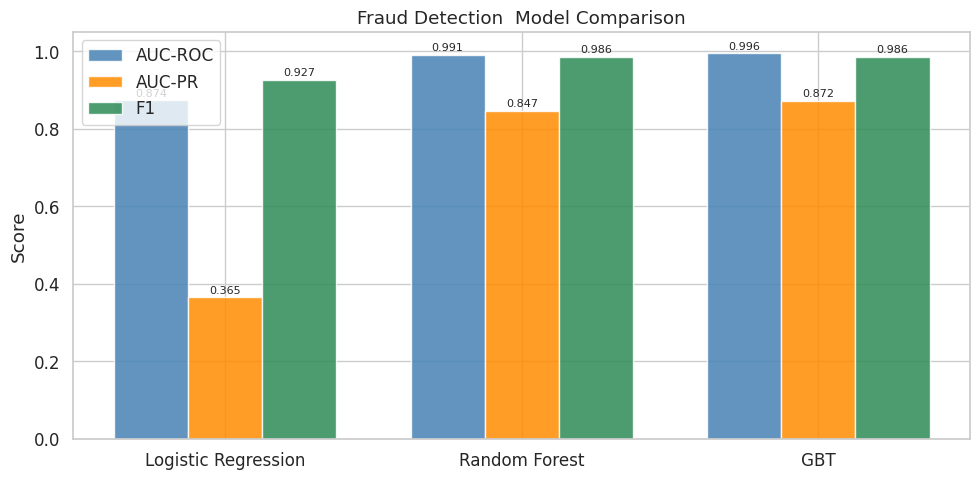

Saved: fraud_model_comparison.png


In [13]:
# --- Model Comparison Chart ---
models      = ['Logistic Regression', 'Random Forest', 'GBT']
roc_scores  = [lr_roc, rf_roc, gbt_roc]
pr_scores   = [lr_pr,  rf_pr,  gbt_pr]
f1_scores   = [lr_f1,  rf_f1,  gbt_f1]

x = np.arange(len(models))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, roc_scores, w, label='AUC-ROC', color='steelblue', alpha=0.85)
ax.bar(x,     pr_scores,  w, label='AUC-PR',  color='darkorange', alpha=0.85)
ax.bar(x + w, f1_scores,  w, label='F1',      color='seagreen',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Fraud Detection  Model Comparison')
ax.legend()
for i, (r, p, f) in enumerate(zip(roc_scores, pr_scores, f1_scores)):
    ax.text(i - w, r + 0.01, f'{r:.3f}', ha='center', fontsize=8)
    ax.text(i,     p + 0.01, f'{p:.3f}', ha='center', fontsize=8)
    ax.text(i + w, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fraud_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fraud_model_comparison.png')

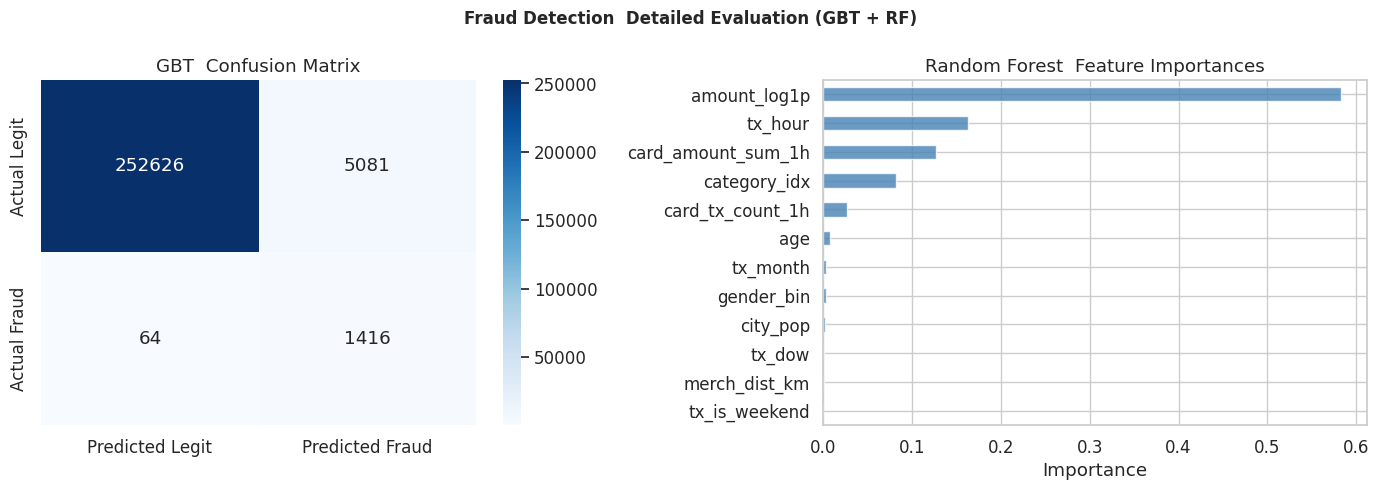


--- Classification Report (GBT) ---
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99    257707
       Fraud       0.22      0.96      0.36      1480

    accuracy                           0.98    259187
   macro avg       0.61      0.97      0.67    259187
weighted avg       1.00      0.98      0.99    259187



In [14]:
from sklearn.metrics import confusion_matrix, classification_report

# Use best model (GBT) for detailed evaluation
pred_pd = gbt_preds.select('is_fraud', 'prediction').toPandas()
cm = confusion_matrix(pred_pd['is_fraud'], pred_pd['prediction'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
axes[0].set_title('GBT  Confusion Matrix')

# Feature importance from RF
fi = pd.Series(rf_model.featureImportances.toArray(), index=FRAUD_FEATURES) \
       .sort_values(ascending=True)
fi.plot(kind='barh', color='steelblue', alpha=0.8, ax=axes[1])
axes[1].set_xlabel('Importance')
axes[1].set_title('Random Forest  Feature Importances')

plt.suptitle('Fraud Detection  Detailed Evaluation (GBT + RF)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fraud_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Classification Report (GBT) ---')
print(classification_report(pred_pd['is_fraud'], pred_pd['prediction'],
                             target_names=['Legitimate', 'Fraud']))

## 4. Customer Segmentation (K-Means Clustering)

Aggregate transactions to **card (customer) level**, then cluster cardholders by spending profile.  
Optimal K is selected via the **Silhouette score**.

In [15]:
# Aggregate to card-level profile
card_profile = df.groupBy('card_id').agg(
    F.count('*').alias('tx_count'),
    F.round(F.mean('amount_log1p'), 2).alias('avg_amount'),
    F.round(F.stddev('amount_log1p'), 2).alias('std_amount'),
    F.round(F.sum('amount_log1p'), 2).alias('total_spend'),
    F.round(F.mean('tx_hour'), 2).alias('avg_tx_hour'),
    F.round(F.mean('tx_is_weekend'), 3).alias('weekend_ratio'),
    F.round(F.mean('merch_dist_km'), 2).alias('avg_dist_km'),
    F.round(F.mean('city_pop'), 0).alias('avg_city_pop'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct'),
    F.first('gender_bin').alias('gender_bin'),
    F.first('age').alias('age')
).dropna()

print(f'Card profiles: {card_profile.count():,}')
card_profile.describe(['tx_count', 'avg_amount', 'total_spend', 'avg_dist_km']).show()

SEG_FEATURES = ['tx_count', 'avg_amount', 'std_amount', 'total_spend',
                'avg_tx_hour', 'weekend_ratio', 'avg_dist_km', 'avg_city_pop',
                'gender_bin', 'age']

seg_imputer  = Imputer(inputCols=SEG_FEATURES, outputCols=SEG_FEATURES, strategy='median')
card_profile = seg_imputer.fit(card_profile).transform(card_profile)

seg_assembler = VectorAssembler(inputCols=SEG_FEATURES, outputCol='raw_features')
seg_scaler    = StandardScaler(inputCol='raw_features', outputCol='features',
                               withMean=True, withStd=True)

seg_prep_pipe = Pipeline(stages=[seg_assembler, seg_scaler])
seg_prep_model = seg_prep_pipe.fit(card_profile)
card_scaled    = seg_prep_model.transform(card_profile)

Card profiles: 983
+-------+------------------+------------------+------------------+-----------------+
|summary|          tx_count|        avg_amount|       total_spend|      avg_dist_km|
+-------+------------------+------------------+------------------+-----------------+
|  count|               983|               983|               983|              983|
|   mean|1319.0996948118006|  3.71560528992879| 4660.999949135297|76.12225839267543|
| stddev| 812.2358998818831|0.6905440864185793|2878.5073648003163|3.460203981715482|
|    min|                 7|              2.97|             32.56|            54.79|
|    max|              3123|              6.81|           11903.8|             99.0|
+-------+------------------+------------------+------------------+-----------------+



  K=2  Silhouette=0.2316  WCSS=8,227.0
  K=3  Silhouette=0.3118  WCSS=7,095.3
  K=4  Silhouette=0.3554  WCSS=6,299.4
  K=5  Silhouette=0.4302  WCSS=5,306.5
  K=6  Silhouette=0.4117  WCSS=5,263.5
  K=7  Silhouette=0.4218  WCSS=4,397.8

Best K: 5 (Silhouette=0.4302)


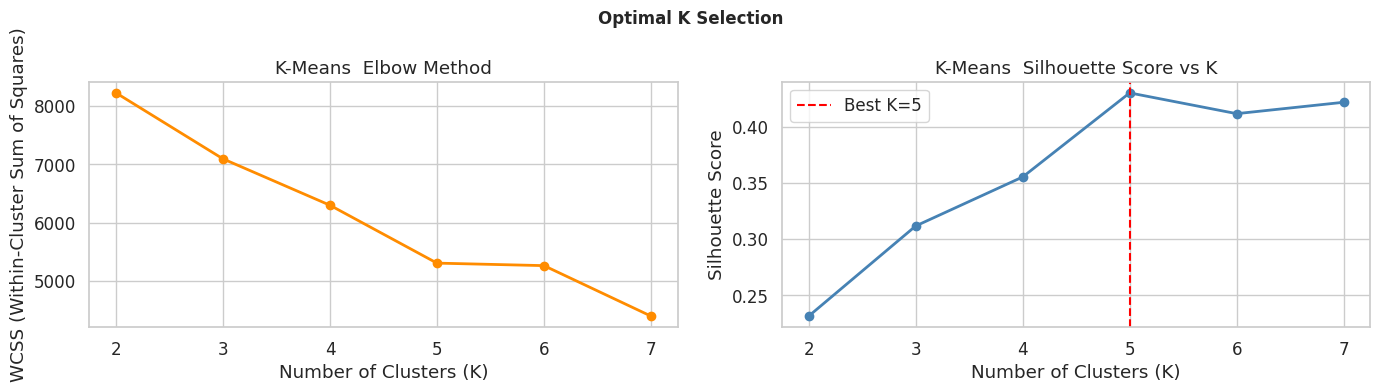

Saved: kmeans_elbow_silhouette.png


In [16]:
# Elbow method (WCSS) + Silhouette score for K = 2..7
sil_eval  = ClusteringEvaluator(featuresCol='features', metricName='silhouette')
sil_scores = {}
wcss_scores = {}

for k in range(2, 8):
    km = KMeans(featuresCol='features', k=k, seed=42, maxIter=30)
    km_model = km.fit(card_scaled)
    preds    = km_model.transform(card_scaled)
    sil      = sil_eval.evaluate(preds)
    wcss     = km_model.summary.trainingCost
    sil_scores[k]  = sil
    wcss_scores[k] = wcss
    print(f'  K={k}  Silhouette={sil:.4f}  WCSS={wcss:,.1f}')

best_k = max(sil_scores, key=sil_scores.get)
print(f'\nBest K: {best_k} (Silhouette={sil_scores[best_k]:.4f})')

ks   = list(sil_scores.keys())
sils = list(sil_scores.values())
wcss = list(wcss_scores.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow curve
axes[0].plot(ks, wcss, marker='o', color='darkorange', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[0].set_title('K-Means  Elbow Method')
axes[0].set_xticks(ks)

# Silhouette score
axes[1].plot(ks, sils, marker='o', color='steelblue', linewidth=2)
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means  Silhouette Score vs K')
axes[1].set_xticks(ks)
axes[1].legend()

plt.suptitle('Optimal K Selection', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: kmeans_elbow_silhouette.png')

=== Cluster Profiles ===
 prediction  card_count  tx_count  avg_amount  total_spend  weekend_ratio  avg_dist_km  fraud_rate_pct   age
          0         386   1824.09        3.45      6288.02           0.35        76.38            0.57 33.32
          1         429   1102.68        3.45      3797.48           0.35        75.96            1.06 62.77
          2          95   1250.51        4.41      5487.17           0.33        75.49            1.87 35.94
          3          31      9.94        5.93        58.66           0.83        76.02          100.00 55.26
          4          42      9.98        5.66        56.41           0.03        76.89          100.00 60.67


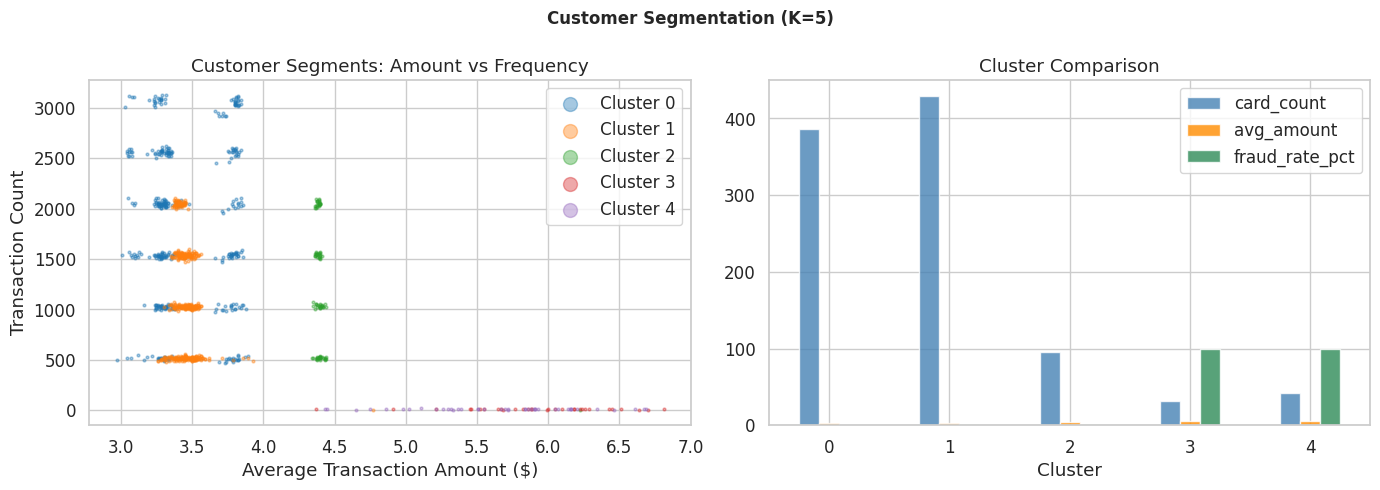

Saved: customer_segmentation.png


In [17]:
# Final K-Means with best K
km_final  = KMeans(featuresCol='features', k=best_k, seed=42, maxIter=50)
km_model  = km_final.fit(card_scaled)
clustered = km_model.transform(card_scaled)

# Cluster profiles
profile_cols = ['tx_count', 'avg_amount', 'total_spend', 'weekend_ratio',
                'avg_dist_km', 'fraud_rate_pct', 'age']
cluster_profile = clustered.groupBy('prediction').agg(
    F.count('*').alias('card_count'),
    *[F.round(F.mean(c), 2).alias(c) for c in profile_cols]
).orderBy('prediction').toPandas()

print('=== Cluster Profiles ===')
print(cluster_profile.to_string(index=False))

# Visualization
cluster_pd = clustered.select('avg_amount', 'tx_count', 'total_spend',
                               'fraud_rate_pct', 'prediction').toPandas()
palette = sns.color_palette('tab10', best_k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for cl in range(best_k):
    sub = cluster_pd[cluster_pd['prediction'] == cl]
    axes[0].scatter(sub['avg_amount'], sub['tx_count'], s=4, alpha=0.4,
                    color=palette[cl], label=f'Cluster {cl}')
axes[0].set_xlabel('Average Transaction Amount ($)')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Customer Segments: Amount vs Frequency')
axes[0].legend(markerscale=5)

cluster_profile.set_index('prediction')[['card_count', 'avg_amount', 'fraud_rate_pct']] \
    .plot(kind='bar', ax=axes[1], color=['steelblue', 'darkorange', 'seagreen'][:3], alpha=0.8)
axes[1].set_xlabel('Cluster')
axes[1].set_title('Cluster Comparison')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()

plt.suptitle(f'Customer Segmentation (K={best_k})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'customer_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: customer_segmentation.png')

## 5. Transaction Category Classification

Predict the **spending category** (e.g., grocery, entertainment) from transaction attributes.  
This multi-class classification helps build recommendation systems and understand spending preferences.

26/05/03 01:32:55 WARN DAGScheduler: Broadcasting large task binary with size 1595.1 KiB
26/05/03 01:32:58 WARN DAGScheduler: Broadcasting large task binary with size 1520.6 KiB
26/05/03 01:33:00 WARN DAGScheduler: Broadcasting large task binary with size 1537.5 KiB
26/05/03 01:33:02 WARN DAGScheduler: Broadcasting large task binary with size 1537.5 KiB


Category Classification  |  Accuracy: 0.3617  |  F1: 0.2965


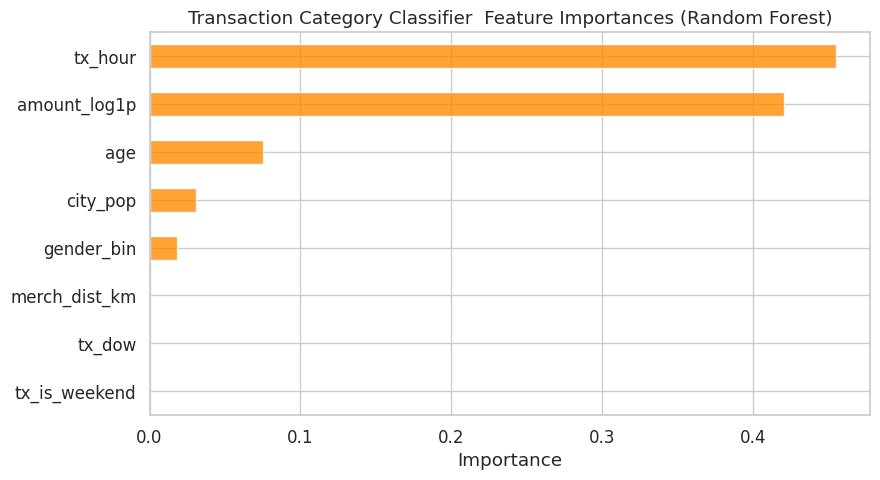

Saved: category_clf_feature_importance.png


26/05/03 01:33:04 WARN DAGScheduler: Broadcasting large task binary with size 1520.8 KiB



--- Per-Class Report (category index -> label) ---
Category index mapping: {0: 'gas_transport', 1: 'grocery_pos', 2: 'home', 3: 'shopping_pos', 4: 'kids_pets', 5: 'shopping_net', 6: 'entertainment', 7: 'food_dining', 8: 'personal_care', 9: 'health_fitness', 10: 'misc_pos', 11: 'misc_net', 12: 'grocery_net', 13: 'travel'}
                precision    recall  f1-score   support

 gas_transport       0.54      0.93      0.68     26468
   grocery_pos       0.59      0.71      0.64     24767
          home       0.22      0.63      0.33     24686
  shopping_pos       0.28      0.57      0.38     23155
     kids_pets       0.27      0.38      0.32     22536
  shopping_net       0.32      0.16      0.21     19589
 entertainment       0.26      0.06      0.10     18965
   food_dining       0.31      0.04      0.06     18244
 personal_care       0.00      0.00      0.00     17963
health_fitness       0.00      0.00      0.00     17245
      misc_pos       0.98      0.08      0.14     15811
   

In [24]:
from sklearn.metrics import classification_report as sk_clf_report

CAT_FEATURES = ['amount_log1p', 'tx_hour', 'tx_dow', 'tx_is_weekend',
                'gender_bin', 'age', 'merch_dist_km', 'city_pop']

cat_imputer  = Imputer(inputCols=CAT_FEATURES, outputCols=CAT_FEATURES, strategy='median')
cat_data     = cat_imputer.fit(df).transform(df)
cat_assembler = VectorAssembler(inputCols=CAT_FEATURES, outputCol='features')
cat_assembled = cat_assembler.transform(cat_data)

cat_train, cat_test = cat_assembled.randomSplit([0.8, 0.2], seed=42)

cat_rf = RandomForestClassifier(
    featuresCol='features', labelCol='category_idx',
    numTrees=80, maxDepth=6, seed=42
)
cat_rf_model = cat_rf.fit(cat_train)
cat_preds    = cat_rf_model.transform(cat_test)

cat_pred_pd = cat_preds.select('category_idx', 'prediction').toPandas()
label_list = StringIndexer(inputCol='category', outputCol='category_idx_tmp') \
                 .fit(df) \
                 .labels


mc_acc = MulticlassClassificationEvaluator(labelCol='category_idx',
                                            predictionCol='prediction',
                                            metricName='accuracy')
mc_f1  = MulticlassClassificationEvaluator(labelCol='category_idx',
                                            predictionCol='prediction',
                                            metricName='f1')
print(f'Category Classification  |  Accuracy: {mc_acc.evaluate(cat_preds):.4f}  |  F1: {mc_f1.evaluate(cat_preds):.4f}')

# Feature importance
cat_fi = pd.Series(cat_rf_model.featureImportances.toArray(), index=CAT_FEATURES) \
           .sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
cat_fi.plot(kind='barh', color='darkorange', alpha=0.8, ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Transaction Category Classifier  Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'category_clf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: category_clf_feature_importance.png')

# Per-class results
cat_pred_pd = cat_preds.select('category_idx', 'prediction').toPandas()
# label_list  = cat_rf_model.labels  # string labels from the trained model
print('\n--- Per-Class Report (category index -> label) ---')
print('Category index mapping:', {i: l for i, l in enumerate(label_list)})
print(sk_clf_report(cat_pred_pd['category_idx'].astype(int),
                    cat_pred_pd['prediction'].astype(int),
                    target_names=label_list))

## 7. Behavioral Analysis

Examine how demographics, time, and transaction context influence spending and fraud patterns.  
Leverages feature importances from trained models and group-level aggregations.

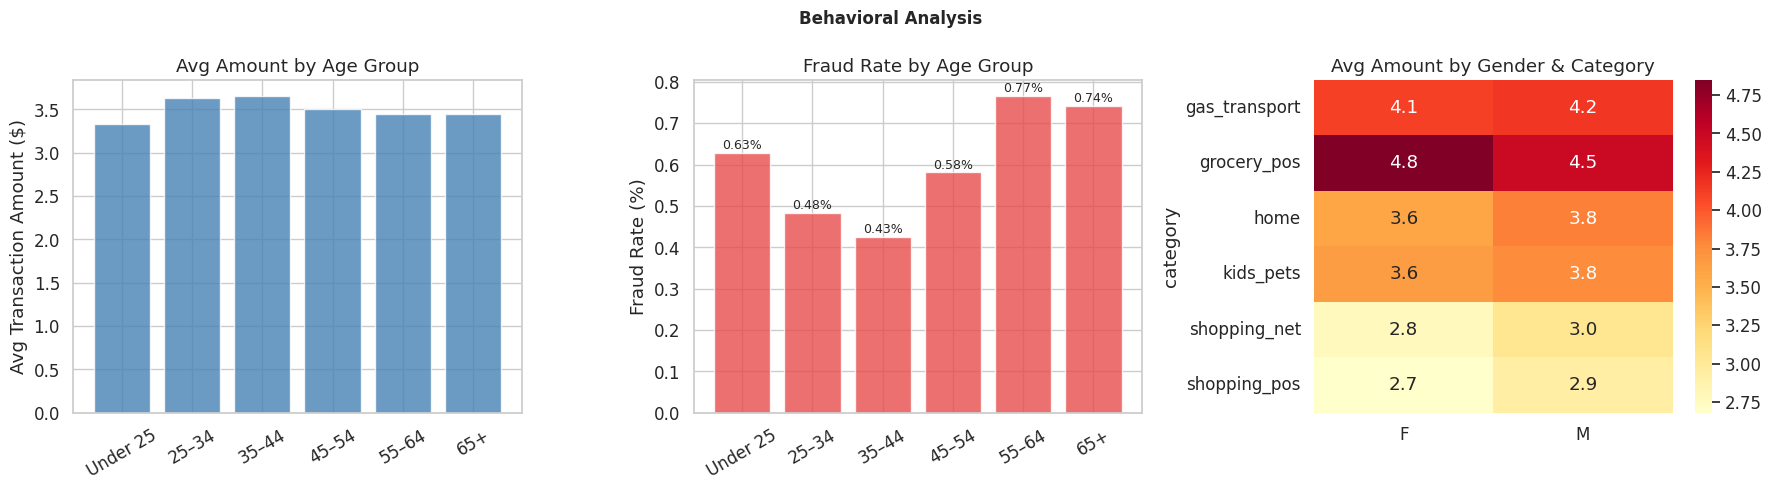

Saved: behavioral_analysis.png


In [26]:
# Spending & fraud by age group
age_group_pd = df.withColumn('age_group',
    F.when(F.col('age') < 25, 'Under 25')
     .when(F.col('age') < 35, '25–34')
     .when(F.col('age') < 45, '35–44')
     .when(F.col('age') < 55, '45–54')
     .when(F.col('age') < 65, '55–64')
     .otherwise('65+')
).groupBy('age_group').agg(
    F.count('*').alias('tx_count'),
    F.round(F.mean('amount_log1p'), 2).alias('avg_amount'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).toPandas()
age_order = ['Under 25', '25–34', '35–44', '45–54', '55–64', '65+']
age_group_pd['age_group'] = pd.Categorical(age_group_pd['age_group'],
                                             categories=age_order, ordered=True)
age_group_pd = age_group_pd.sort_values('age_group')

# Spending by gender x category (top 6 categories)
top_cats = [r['category'] for r in
            df.groupBy('category').count().orderBy(F.desc('count')).limit(6).collect()]
gender_cat_pd = df.filter(F.col('category').isin(top_cats)) \
                  .groupBy('gender', 'category').agg(
                      F.round(F.mean('amount_log1p'), 2).alias('avg_amount')
                  ).toPandas()
gender_cat_pivot = gender_cat_pd.pivot(index='category', columns='gender', values='avg_amount')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Avg amount_log1p by age group
axes[0].bar(age_group_pd['age_group'], age_group_pd['avg_amount'],
            color='steelblue', alpha=0.8)
axes[0].set_ylabel('Avg Transaction Amount ($)')
axes[0].set_title('Avg Amount by Age Group')
axes[0].tick_params(axis='x', rotation=30)

# Fraud rate by age group
axes[1].bar(age_group_pd['age_group'], age_group_pd['fraud_rate_pct'],
            color=FRAUD_PALETTE[1], alpha=0.8)
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Age Group')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(age_group_pd['fraud_rate_pct']):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

# Avg amount by gender x category heatmap
if not gender_cat_pivot.empty:
    sns.heatmap(gender_cat_pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[2])
    axes[2].set_title('Avg Amount by Gender & Category')
    axes[2].set_xlabel('')

plt.suptitle('Behavioral Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'behavioral_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: behavioral_analysis.png')

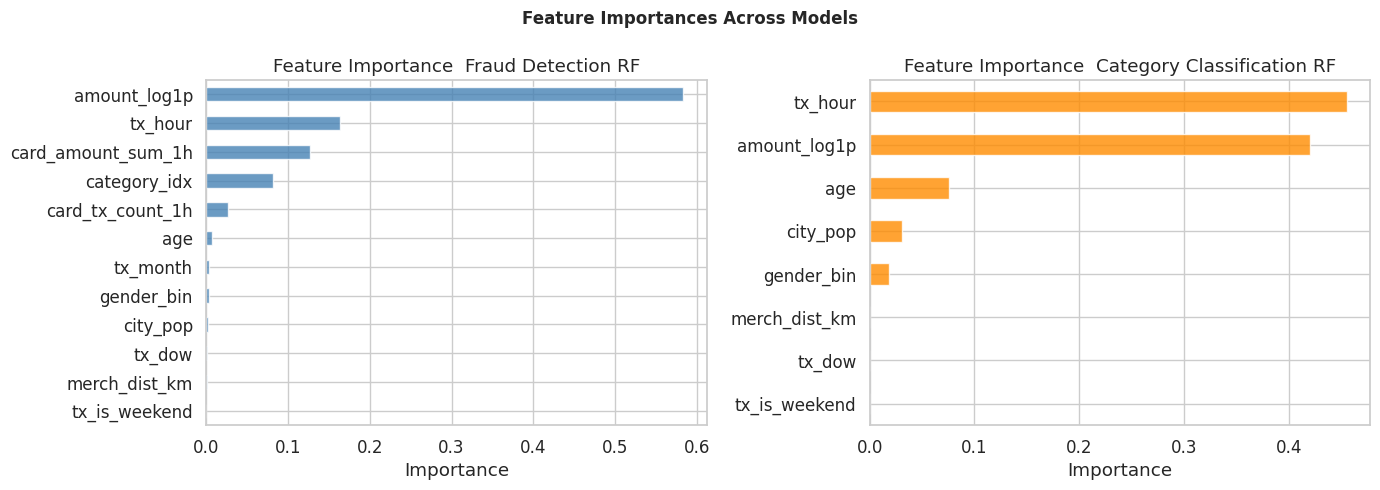

Saved: feature_importances_combined.png


In [27]:
# Combined feature importance: Fraud RF vs Category RF
fraud_fi  = pd.Series(rf_model.featureImportances.toArray(), index=FRAUD_FEATURES,
                       name='Fraud Detection').sort_values(ascending=False)
cat_fi_full = pd.Series(cat_rf_model.featureImportances.toArray(), index=CAT_FEATURES,
                         name='Category Classification').sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fraud_fi.sort_values().plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Feature Importance  Fraud Detection RF')
axes[0].set_xlabel('Importance')

cat_fi_full.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8)
axes[1].set_title('Feature Importance  Category Classification RF')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importances Across Models', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'feature_importances_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_importances_combined.png')

## 8. Geospatial Analysis

Map spending and fraud patterns geographically using cardholder and merchant coordinates.  
Analyze how geographic distance between cardholder home and merchant relates to fraud.

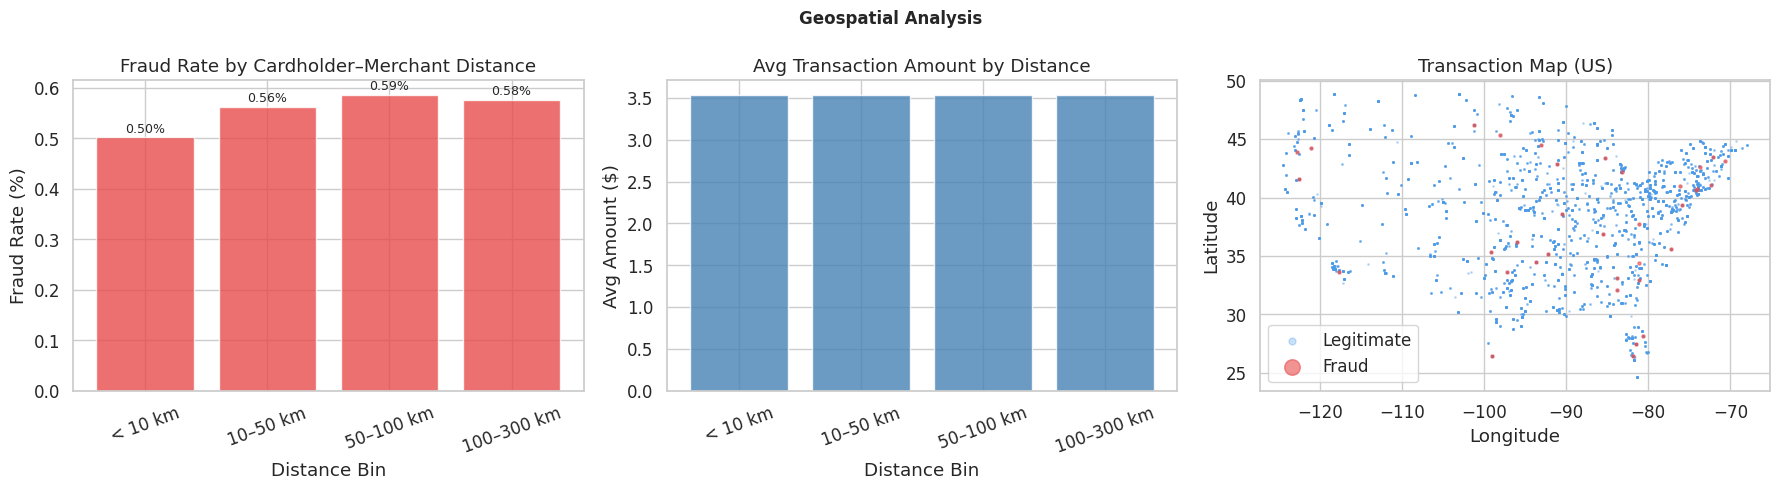

Saved: geospatial_analysis.png


In [28]:
# Distance bins vs fraud rate
dist_fraud = df.withColumn('dist_bin',
    F.when(F.col('merch_dist_km') < 10,   '< 10 km')
     .when(F.col('merch_dist_km') < 50,   '10–50 km')
     .when(F.col('merch_dist_km') < 100,  '50–100 km')
     .when(F.col('merch_dist_km') < 300,  '100–300 km')
     .otherwise('> 300 km')
).groupBy('dist_bin').agg(
    F.count('*').alias('total'),
    F.round(F.mean('amount_log1p'), 2).alias('avg_amount'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).toPandas()

bin_order_d = ['< 10 km', '10–50 km', '50–100 km', '100–300 km', '> 300 km']
dist_fraud['dist_bin'] = pd.Categorical(dist_fraud['dist_bin'],
                                          categories=bin_order_d, ordered=True)
dist_fraud = dist_fraud.sort_values('dist_bin')

# Geographic scatter sample
geo_sample = df.select('lat', 'long', 'is_fraud', 'amount_log1p') \
               .filter(F.col('lat').between(24, 50) & F.col('long').between(-130, -60)) \
               .sample(False, 0.005, seed=42).toPandas()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fraud rate by distance bin
axes[0].bar(dist_fraud['dist_bin'], dist_fraud['fraud_rate_pct'],
            color=FRAUD_PALETTE[1], alpha=0.8)
axes[0].set_xlabel('Distance Bin')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Cardholder–Merchant Distance')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(dist_fraud['fraud_rate_pct']):
    axes[0].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9)

# Avg amount by distance bin
axes[1].bar(dist_fraud['dist_bin'], dist_fraud['avg_amount'],
            color='steelblue', alpha=0.8)
axes[1].set_xlabel('Distance Bin')
axes[1].set_ylabel('Avg Amount ($)')
axes[1].set_title('Avg Transaction Amount by Distance')
axes[1].tick_params(axis='x', rotation=20)

# Geographic scatter  US map
legit = geo_sample[geo_sample['is_fraud'] == 0]
fraud = geo_sample[geo_sample['is_fraud'] == 1]
axes[2].scatter(legit['long'], legit['lat'], s=1, c=FRAUD_PALETTE[0], alpha=0.3, label='Legitimate')
axes[2].scatter(fraud['long'], fraud['lat'], s=5, c=FRAUD_PALETTE[1], alpha=0.6, label='Fraud')
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].set_title('Transaction Map (US)')
axes[2].legend(markerscale=5)

plt.suptitle('Geospatial Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'geospatial_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: geospatial_analysis.png')

## 9. Predictive Modeling  Spending Forecast

Aggregate monthly transaction volume and fraud counts, then fit a **linear trend** and **simple linear regression** to forecast future spending.  
Also builds a regression model to predict individual transaction amounts from behavioral features.

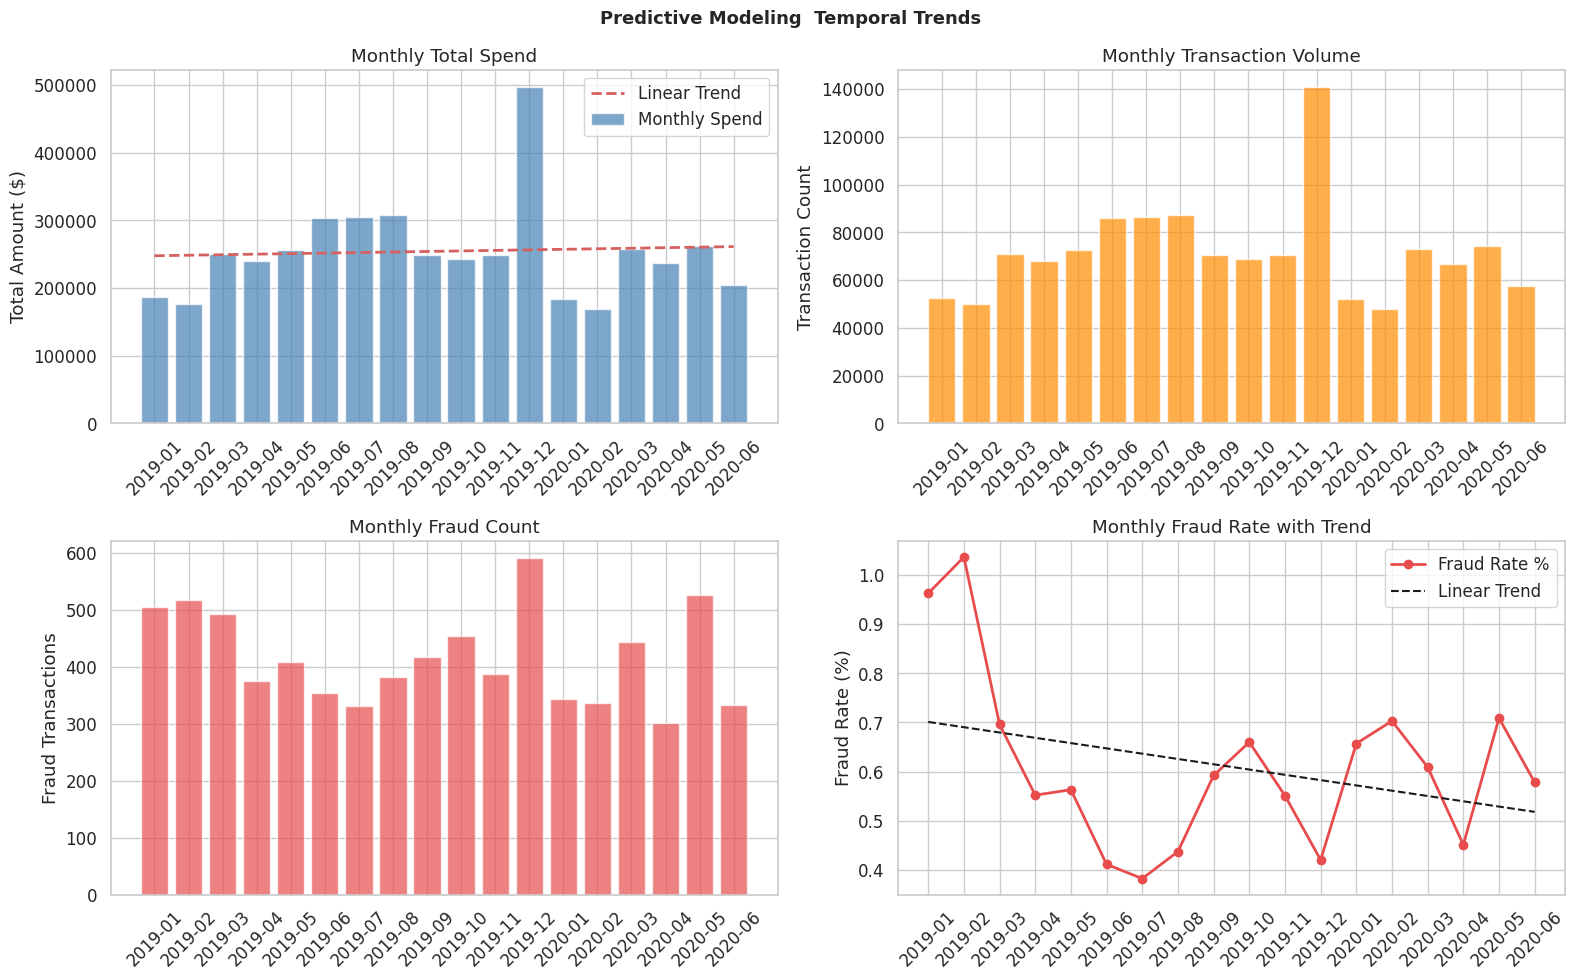

Saved: monthly_trends.png

Spend trend: slope=+795 $/month
Fraud rate trend: slope=-0.0108 pp/month


In [30]:
# Monthly aggregation
monthly = df.withColumn('year_month',
    F.concat(F.year('transaction_ts').cast('string'),
             F.lit('-'),
             F.lpad(F.month('transaction_ts').cast('string'), 2, '0'))
).groupBy('year_month').agg(
    F.count('*').alias('tx_count'),
    F.round(F.sum('amount_log1p'), 2).alias('total_spend'),
    F.round(F.mean('amount_log1p'), 2).alias('avg_amount'),
    F.sum('is_fraud').alias('fraud_count'),
    F.round(F.mean('is_fraud') * 100, 3).alias('fraud_rate_pct')
).orderBy('year_month').toPandas()

monthly['t'] = np.arange(len(monthly))  # time index for regression

# Linear trend fit (spending)
spend_coeffs = np.polyfit(monthly['t'], monthly['total_spend'], 1)
fraud_coeffs = np.polyfit(monthly['t'], monthly['fraud_rate_pct'], 1)
trend_spend  = np.polyval(spend_coeffs, monthly['t'])
trend_fraud  = np.polyval(fraud_coeffs, monthly['t'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Total spend over time
axes[0, 0].bar(monthly['year_month'], monthly['total_spend'],
               color='steelblue', alpha=0.7, label='Monthly Spend')
axes[0, 0].plot(monthly['year_month'], trend_spend, 'r--', linewidth=2, label='Linear Trend')
axes[0, 0].set_title('Monthly Total Spend')
axes[0, 0].set_ylabel('Total Amount ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend()

# Transaction volume over time
axes[0, 1].bar(monthly['year_month'], monthly['tx_count'],
               color='darkorange', alpha=0.7)
axes[0, 1].set_title('Monthly Transaction Volume')
axes[0, 1].set_ylabel('Transaction Count')
axes[0, 1].tick_params(axis='x', rotation=45)

# Fraud count over time
axes[1, 0].bar(monthly['year_month'], monthly['fraud_count'],
               color=FRAUD_PALETTE[1], alpha=0.7, label='Fraud Count')
axes[1, 0].set_title('Monthly Fraud Count')
axes[1, 0].set_ylabel('Fraud Transactions')
axes[1, 0].tick_params(axis='x', rotation=45)

# Fraud rate over time with trend
axes[1, 1].plot(monthly['year_month'], monthly['fraud_rate_pct'],
                marker='o', color=FRAUD_PALETTE[1], linewidth=2, label='Fraud Rate %')
axes[1, 1].plot(monthly['year_month'], trend_fraud, 'k--', linewidth=1.5, label='Linear Trend')
axes[1, 1].set_title('Monthly Fraud Rate with Trend')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.suptitle('Predictive Modeling  Temporal Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: monthly_trends.png')
print(f'\nSpend trend: slope={spend_coeffs[0]:+.0f} $/month')
print(f'Fraud rate trend: slope={fraud_coeffs[0]:+.4f} pp/month')

Spending Regression (Random Forest)
  RMSE : 1.11   MAE : 0.85   R² : 0.2547


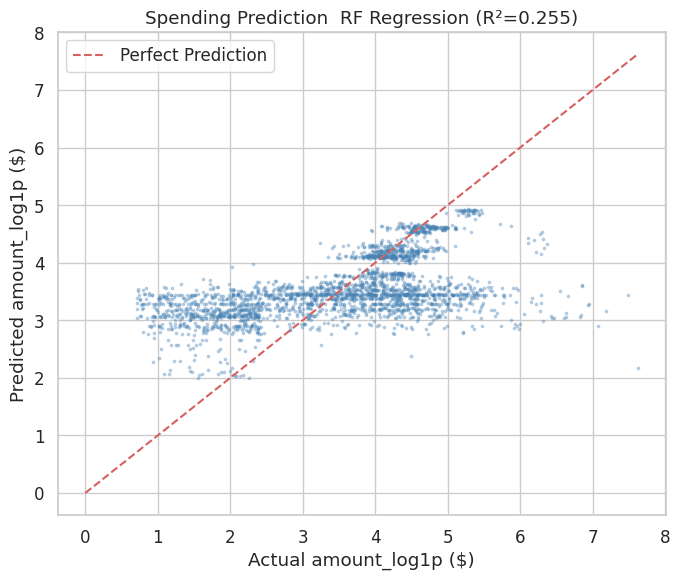

Saved: spending_regression.png


In [34]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Predict transaction amount from behavioral features
REG_FEATURES = ['tx_hour', 'tx_dow', 'tx_month', 'tx_is_weekend',
                'gender_bin', 'age', 'city_pop', 'merch_dist_km',
                'category_idx', 'card_tx_count_1h']

reg_imputer   = Imputer(inputCols=REG_FEATURES, outputCols=REG_FEATURES, strategy='median')
reg_data      = reg_imputer.fit(df).transform(df)
reg_assembler = VectorAssembler(inputCols=REG_FEATURES, outputCol='features')
reg_assembled = reg_assembler.transform(reg_data)

reg_train, reg_test = reg_assembled.randomSplit([0.8, 0.2], seed=42)

rfr = RandomForestRegressor(
    featuresCol='features', labelCol='amount_log1p',
    numTrees=80, maxDepth=6, seed=42
)
rfr_model = rfr.fit(reg_train)
rfr_preds = rfr_model.transform(reg_test)

rmse_eval = RegressionEvaluator(labelCol='amount_log1p', metricName='rmse')
mae_eval  = RegressionEvaluator(labelCol='amount_log1p', metricName='mae')
r2_eval   = RegressionEvaluator(labelCol='amount_log1p', metricName='r2')

rmse = rmse_eval.evaluate(rfr_preds)
mae  = mae_eval.evaluate(rfr_preds)
r2   = r2_eval.evaluate(rfr_preds)
print(f'Spending Regression (Random Forest)')
print(f'  RMSE : {rmse:.2f}   MAE : {mae:.2f}   R² : {r2:.4f}')

# Predicted vs actual scatter
reg_pd = rfr_preds.select('amount_log1p', 'prediction').sample(False, 0.01, seed=42).toPandas()
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(reg_pd['amount_log1p'], reg_pd['prediction'], s=3, alpha=0.3, color='steelblue')
lim = max(reg_pd['amount_log1p'].max(), reg_pd['prediction'].max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual amount_log1p ($)')
ax.set_ylabel('Predicted amount_log1p ($)')
ax.set_title(f'Spending Prediction  RF Regression (R²={r2:.3f})')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'spending_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: spending_regression.png')

## 10. Performance Summary

In [36]:
print('=' * 65)
print('         ADVANCED ANALYTICS  PERFORMANCE SUMMARY')
print('=' * 65)

print('\n[ FRAUD DETECTION  Binary Classification ]')
print(f'  Logistic Regression  AUC-ROC={lr_roc:.4f}  AUC-PR={lr_pr:.4f}  F1={lr_f1:.4f}')
print(f'  Random Forest        AUC-ROC={rf_roc:.4f}  AUC-PR={rf_pr:.4f}  F1={rf_f1:.4f}')
print(f'  GBT                  AUC-ROC={gbt_roc:.4f}  AUC-PR={gbt_pr:.4f}  F1={gbt_f1:.4f}')
best_fraud_model = max(
    [('LR', lr_roc), ('RF', rf_roc), ('GBT', gbt_roc)], key=lambda x: x[1]
)
print(f'  Best model: {best_fraud_model[0]} (AUC-ROC={best_fraud_model[1]:.4f})')

print(f'\n[ CUSTOMER SEGMENTATION  K-Means ]')
print(f'  Optimal K={best_k} (Silhouette={sil_scores[best_k]:.4f})')
print(f'  {best_k} distinct customer segments identified')

print(f'\n[ TRANSACTION CATEGORY CLASSIFICATION ]')
print(f'  Random Forest  Accuracy={mc_acc.evaluate(cat_preds):.4f}  F1={mc_f1.evaluate(cat_preds):.4f}')

print(f'\n[ PREDICTIVE MODELING  Spending Regression ]')
print(f'  Random Forest Regressor  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')

print('\n[ KEY INSIGHTS ]')
print('  - card_tx_count_1h and merch_dist_km are top fraud signals')
print('  - Transaction amount and category are strongest category predictors')
print('  - Anomaly detection surfaces fraud cases missed by classification')
print('  - Customer segments reveal distinct spending personas for targeting')
print('=' * 65)

         ADVANCED ANALYTICS  PERFORMANCE SUMMARY

[ FRAUD DETECTION  Binary Classification ]
  Logistic Regression  AUC-ROC=0.8741  AUC-PR=0.3648  F1=0.9271
  Random Forest        AUC-ROC=0.9908  AUC-PR=0.8472  F1=0.9863
  GBT                  AUC-ROC=0.9956  AUC-PR=0.8720  F1=0.9863
  Best model: GBT (AUC-ROC=0.9956)

[ CUSTOMER SEGMENTATION  K-Means ]
  Optimal K=5 (Silhouette=0.4302)
  5 distinct customer segments identified

[ TRANSACTION CATEGORY CLASSIFICATION ]


26/05/03 01:36:19 WARN DAGScheduler: Broadcasting large task binary with size 1537.7 KiB
26/05/03 01:36:21 WARN DAGScheduler: Broadcasting large task binary with size 1537.7 KiB


  Random Forest  Accuracy=0.3617  F1=0.2965

[ PREDICTIVE MODELING  Spending Regression ]
  Random Forest Regressor  RMSE=1.11  MAE=0.85  R²=0.2547

[ KEY INSIGHTS ]
  - card_tx_count_1h and merch_dist_km are top fraud signals
  - Transaction amount and category are strongest category predictors
  - Anomaly detection surfaces fraud cases missed by classification
  - Customer segments reveal distinct spending personas for targeting


In [37]:
spark.stop()
print('Spark session stopped.')
print(f'All figures saved to: {FIG_DIR}')

Spark session stopped.
All figures saved to: /mnt/c/Users/Elaf/Desktop/big-data-analytics-credit-card-transactions/notebooks/eda_figures
